In [1]:
import os
HOME = os.getcwd()
print(HOME)

/tf/extra/phitchakorn/src


In [2]:
!pip install ultralytics==8.0.28

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.28 🚀 Python-3.8.10 torch-2.0.1+cu117 CPU
Setup complete ✅ (80 CPUs, 503.3 GB RAM, 381.5/438.5 GB disk)


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

In [1]:
# !jupyter notebook --NotebookApp.iopub_msg_rate_limit=10000.0 --NotebookApp.iopub_data_rate_limit=1.0e10


  _   _          _      _
 | | | |_ __  __| |__ _| |_ ___
 | |_| | '_ \/ _` / _` |  _/ -_)
  \___/| .__/\__,_\__,_|\__\___|
       |_|
                       
Read the migration plan to Notebook 7 to learn about the new features and the actions to take if you are using extensions.

https://jupyter-notebook.readthedocs.io/en/latest/migrate_to_notebook7.html

Please note that updating to Notebook 7 might break some of your extensions.

jupyter_http_over_ws extension initialized. Listening on /http_over_websocket
[C 07:41:36.501 NotebookApp] Running as root is not recommended. Use --allow-root to bypass.


In [4]:
!yolo task=segment mode=train model=yolov8s-seg.pt data=data.yaml epochs=300 imgsz=640 save=true

Ultralytics YOLOv8.0.28 🚀 Python-3.8.10 torch-2.0.1+cu117 CPU
yolo/engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=data.yaml, epochs=300, patience=50, batch=16, imgsz=640, save=True, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, simplify=False, opset=None, workspace=4, nms=False, lr0=0.01, lrf=0.01

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [5]:
!ls runs/segment/train/

args.yaml					     train_batch0.jpg
events.out.tfevents.1782468726.357022f798d1.67600.0  train_batch1.jpg
results.csv					     train_batch2.jpg
results.png					     weights


In [7]:
Image(filename=f'runs/segment/train/confusion_matrix.png', width=600)

FileNotFoundError: [Errno 2] No such file or directory: 'runs/segment/train/confusion_matrix.png'

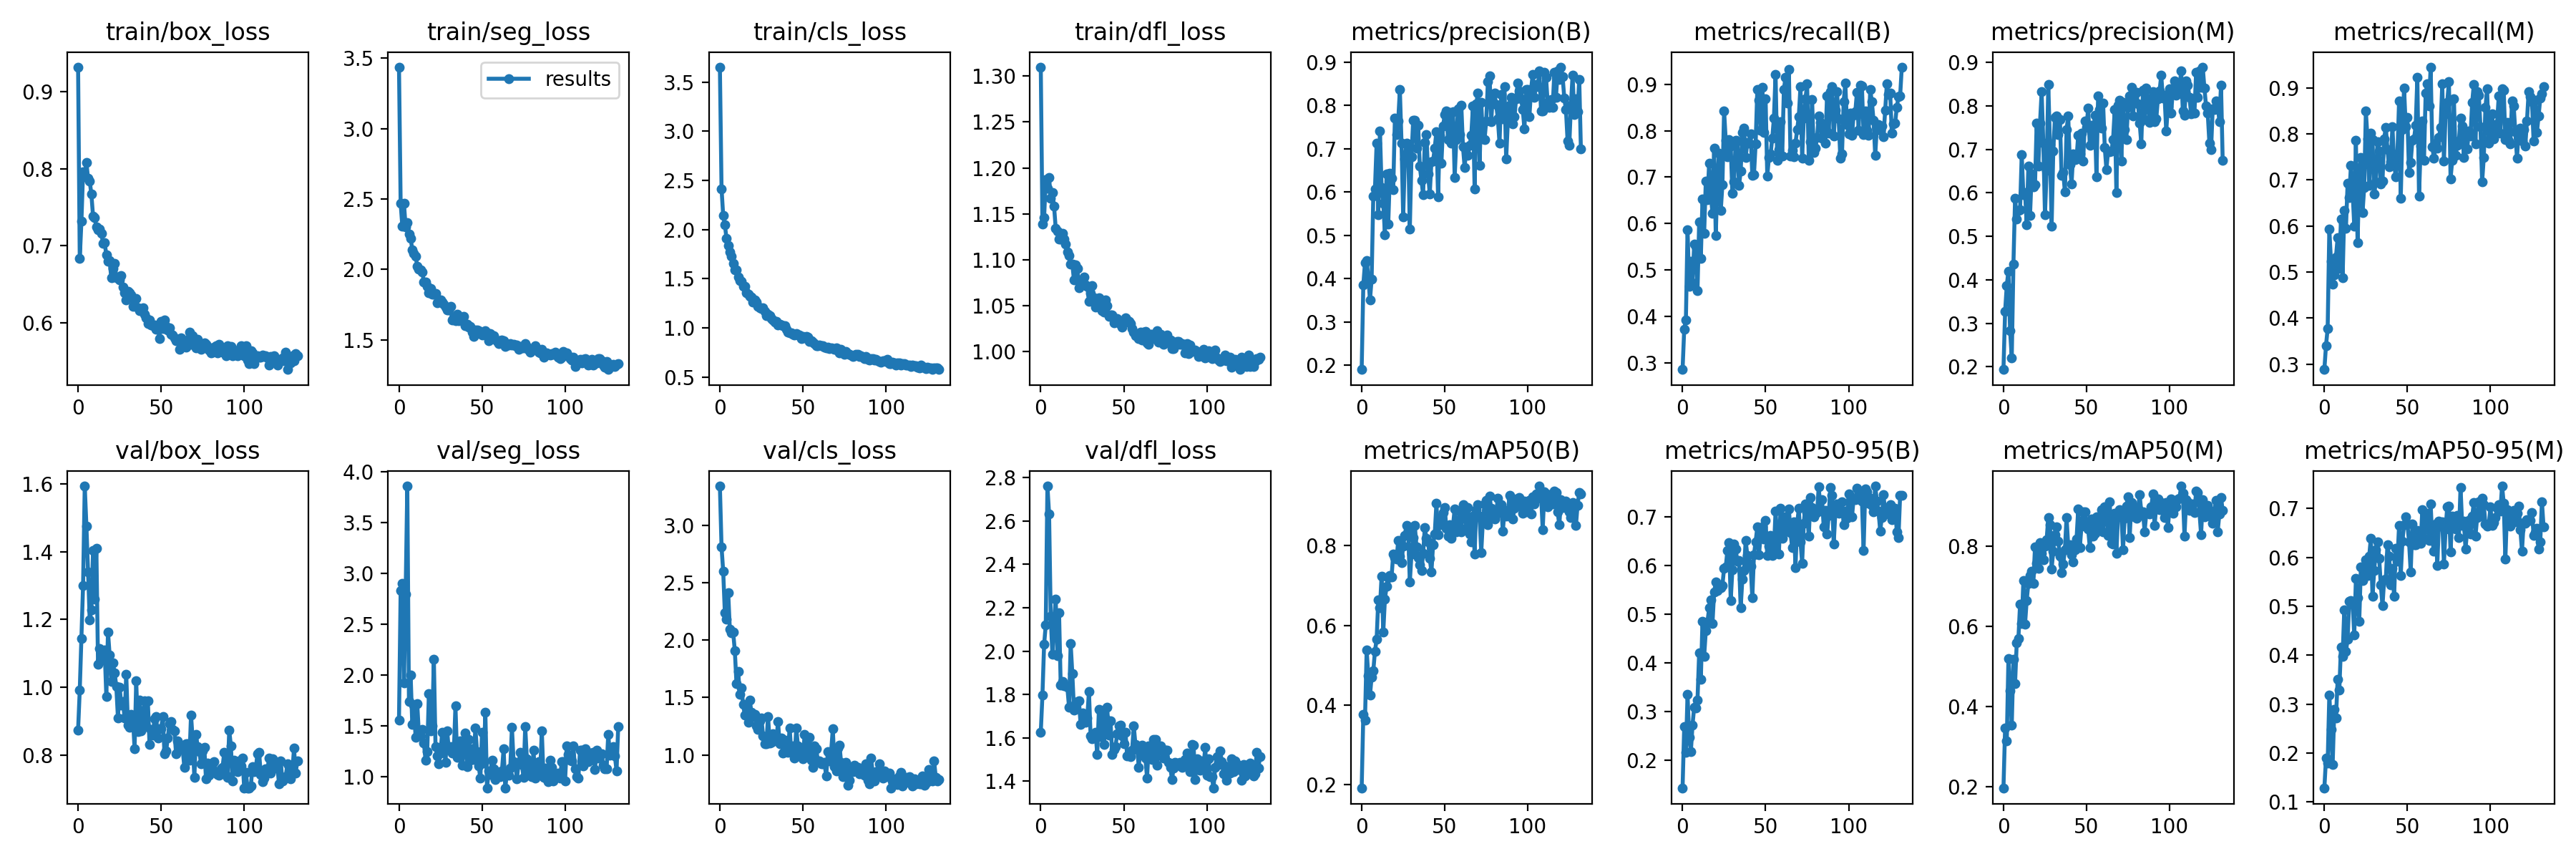

In [6]:
Image(filename=f'runs/segment/train/results.png', width=600)

In [8]:
Image(filename=f'runs/segment/train/val_batch0_pred.jpg', width=600)

FileNotFoundError: [Errno 2] No such file or directory: 'runs/segment/train/val_batch0_pred.jpg'

In [9]:
!yolo task=segment mode=val model=runs/segment/train/weights/best.pt data=data.yaml

2026-06-29 07:30:52.637273: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 07:30:52.682252: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Ultralytics YOLOv8.0.28 🚀 Python-3.8.10 torch-2.0.1+cu117 CPU
YOLOv8s-seg summary (fused): 195 layers, 11785405 parameters, 0 gradients, 42.5 GFLOPs
val: Scanning /tf/extra/phitchakorn/src/datasets/V3YOL8-segmentation/valid/label
/usr/local/lib/python3.8/dist-packages/torch/cuda/__init__.py:546: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
 

In [14]:
!yolo task=segment mode=predict model=runs/segment/train/weights/best.pt conf=0.25 source=datasets/V3YOL8-segmentation/test/images save=true

2026-06-29 07:32:54.737553: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 07:32:54.783061: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Ultralytics YOLOv8.0.28 🚀 Python-3.8.10 torch-2.0.1+cu117 CPU
YOLOv8s-seg summary (fused): 195 layers, 11785405 parameters, 0 gradients, 42.5 GFLOPs

image 1/26 /tf/extra/phitchakorn/src/datasets/V3YOL8-segmentation/test/images/Bungarus-candidus11_jpg.rf.c1b789ef0a0ec138efd907f35ece5f8a.jpg: 640x640 1 Bungarus candidus, 77.5ms
image 2/26 /tf/extra/phitchakorn/src/datasets

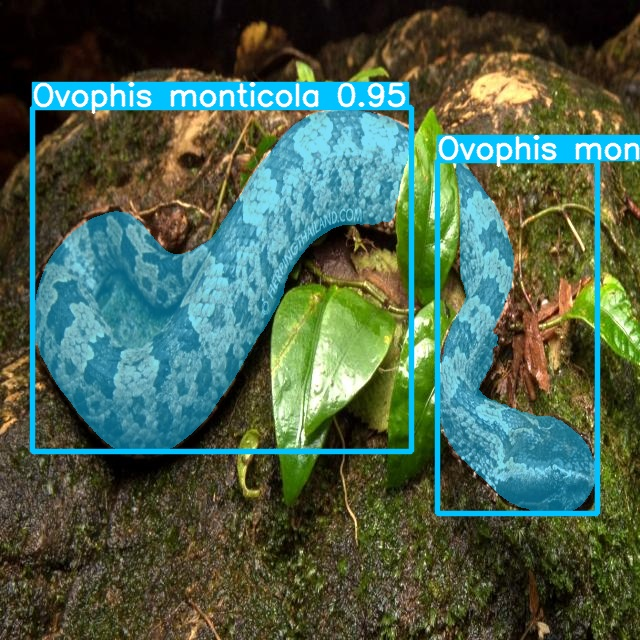

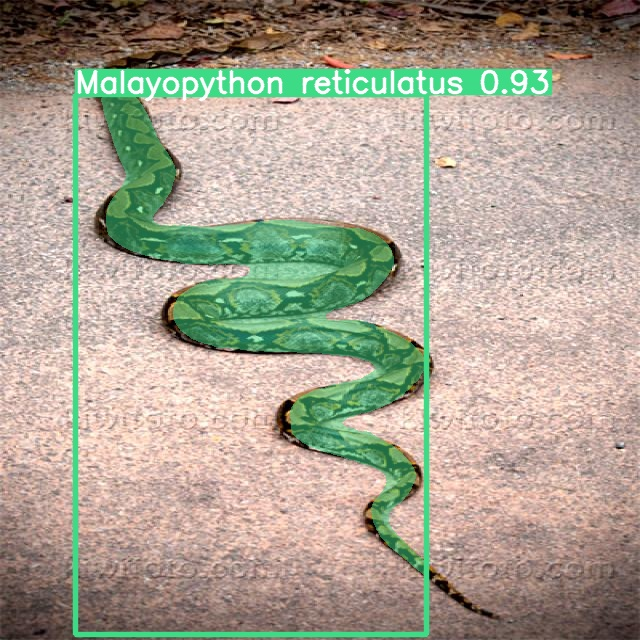

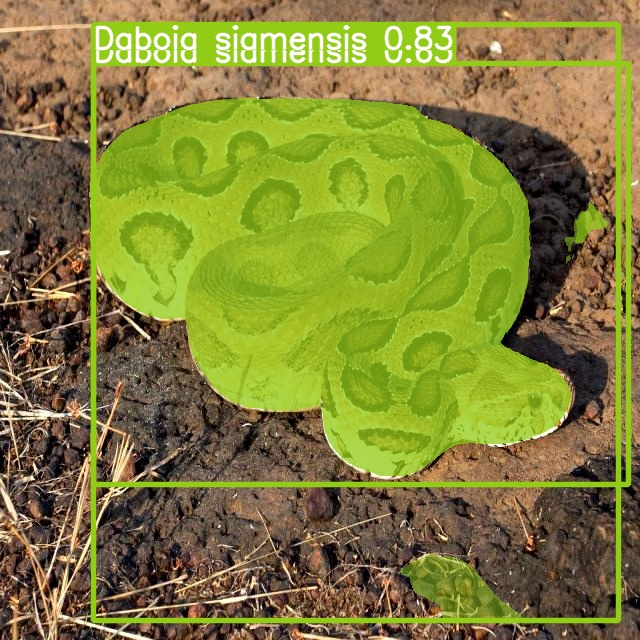

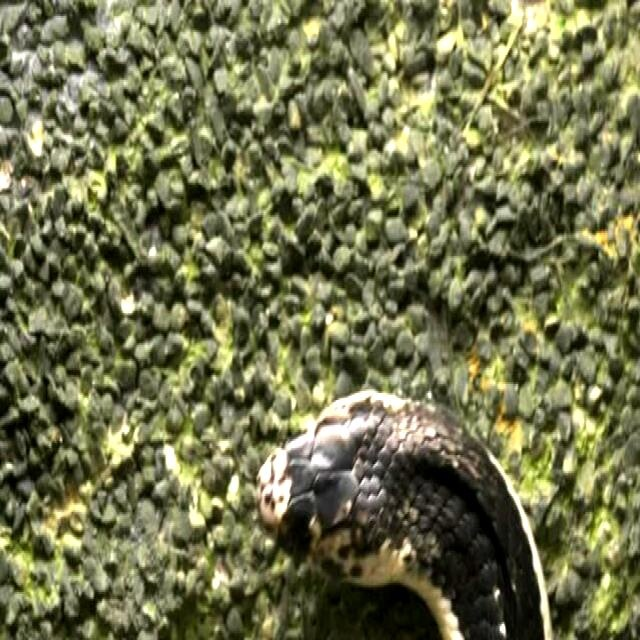

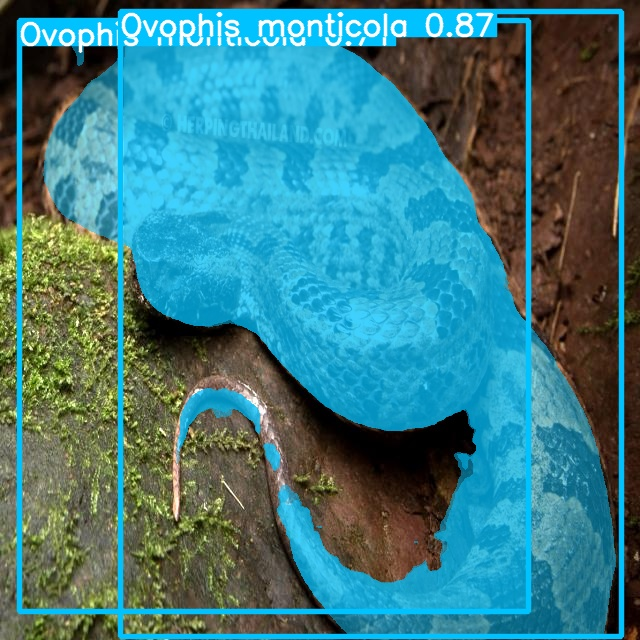

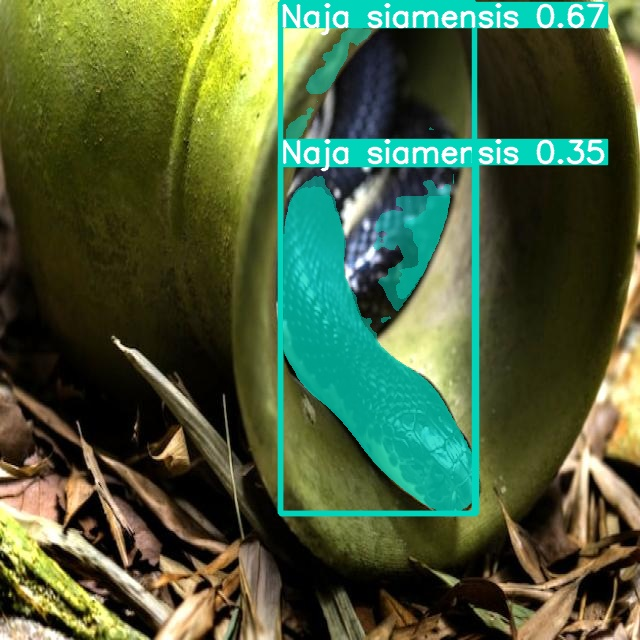

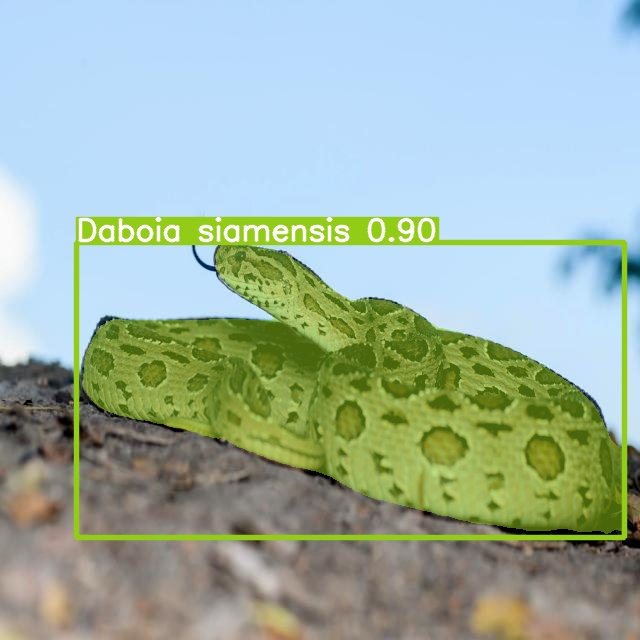

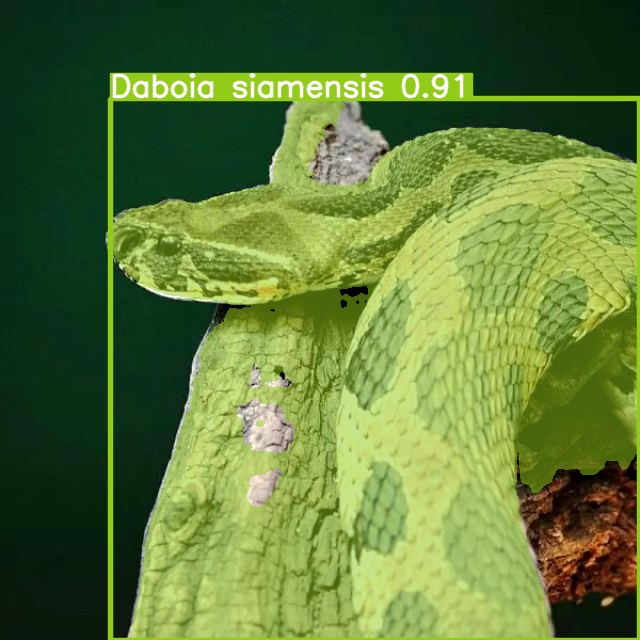

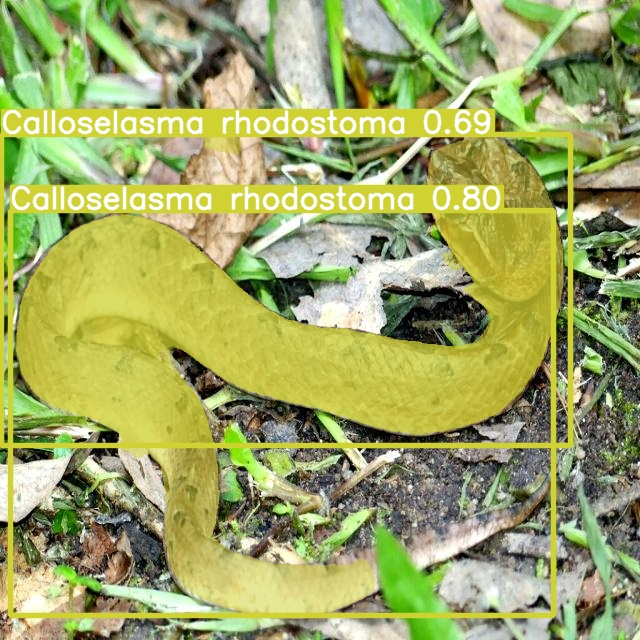

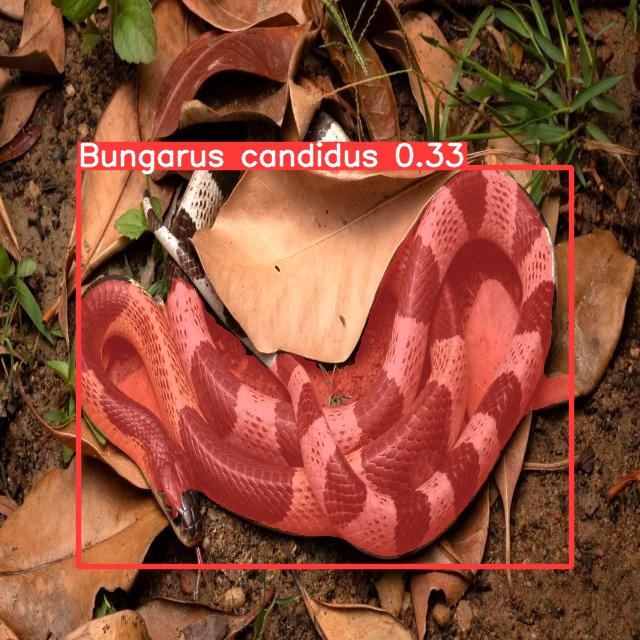

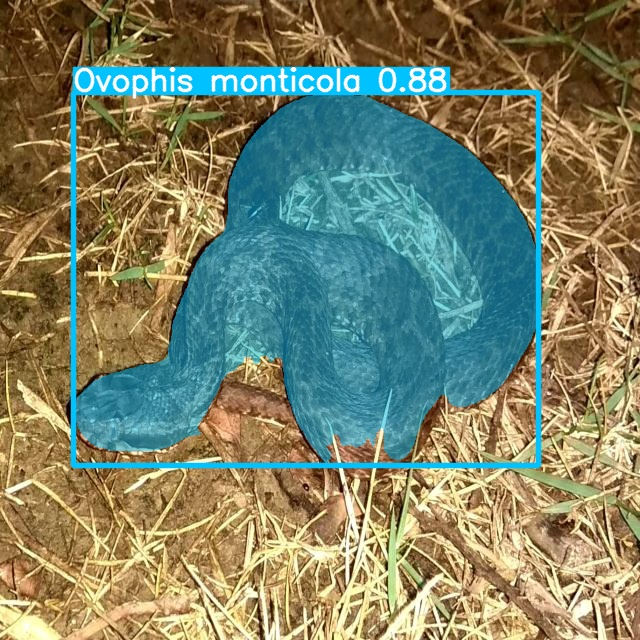

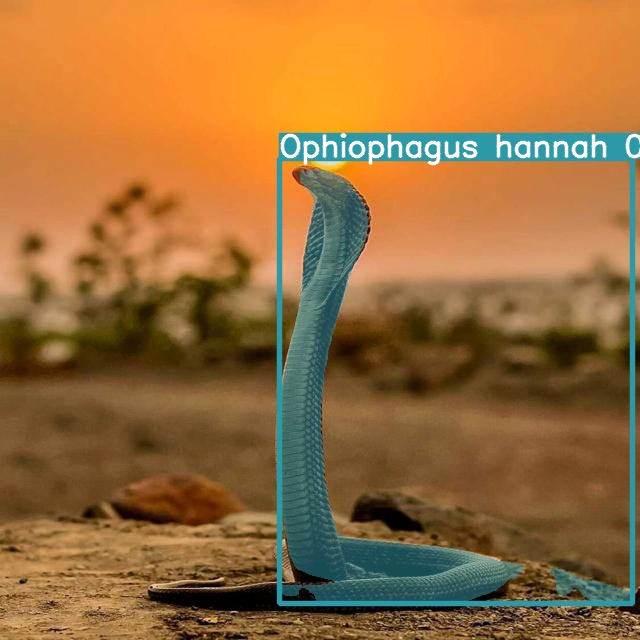

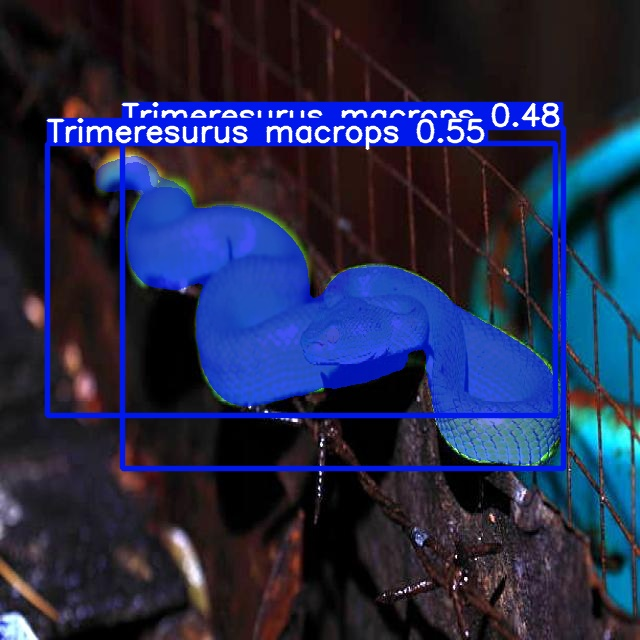

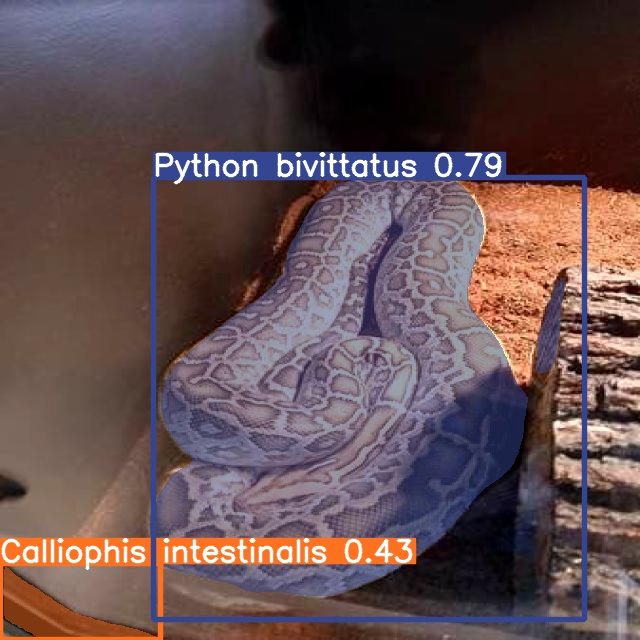

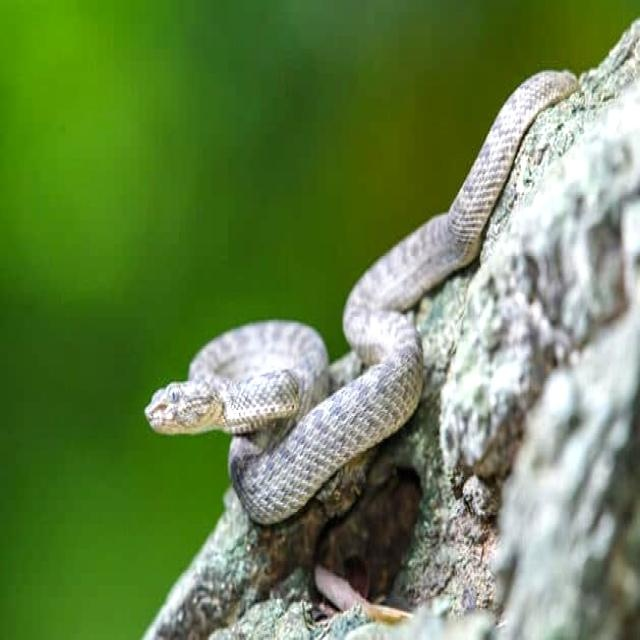

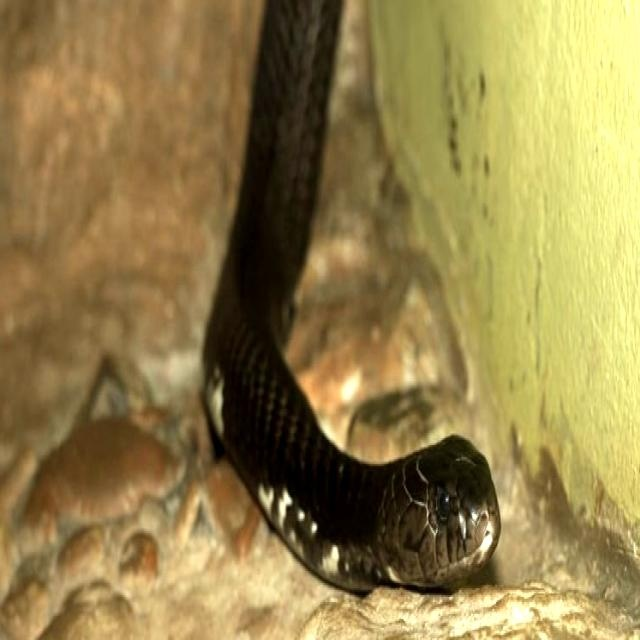

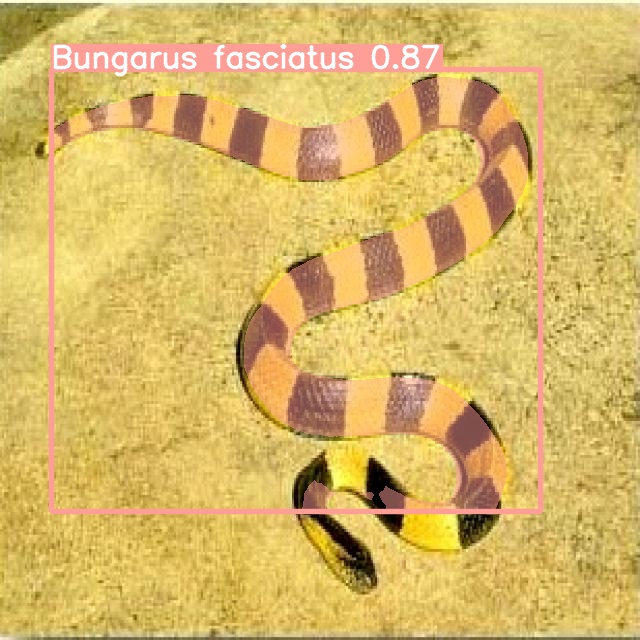

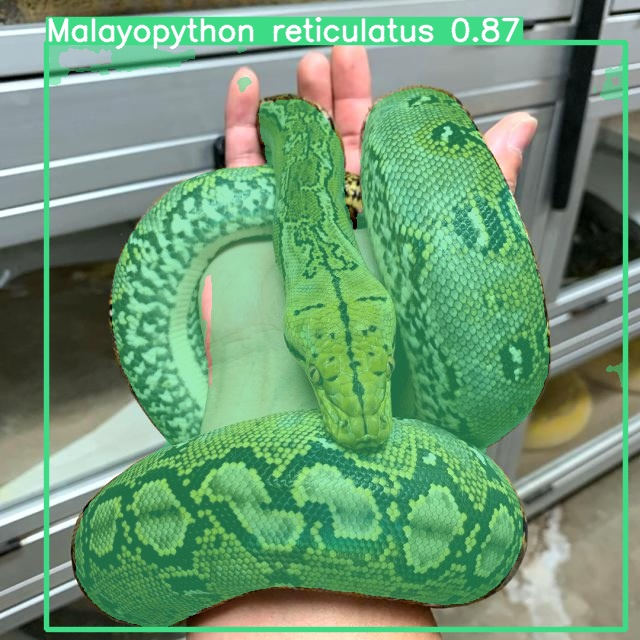

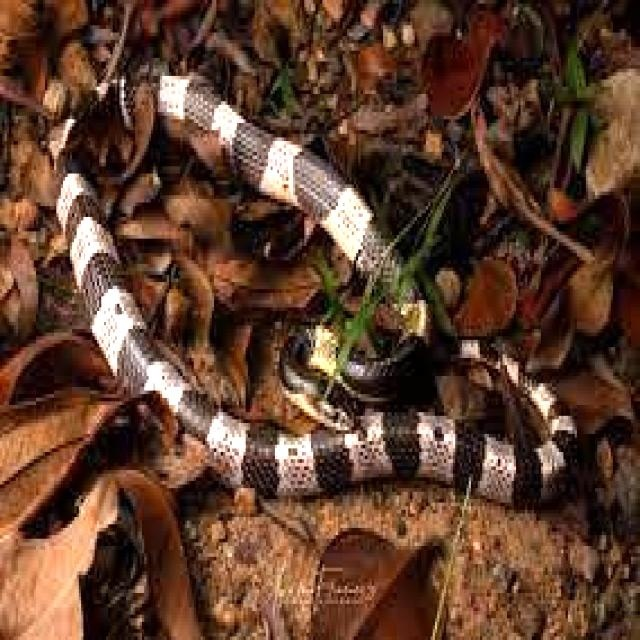

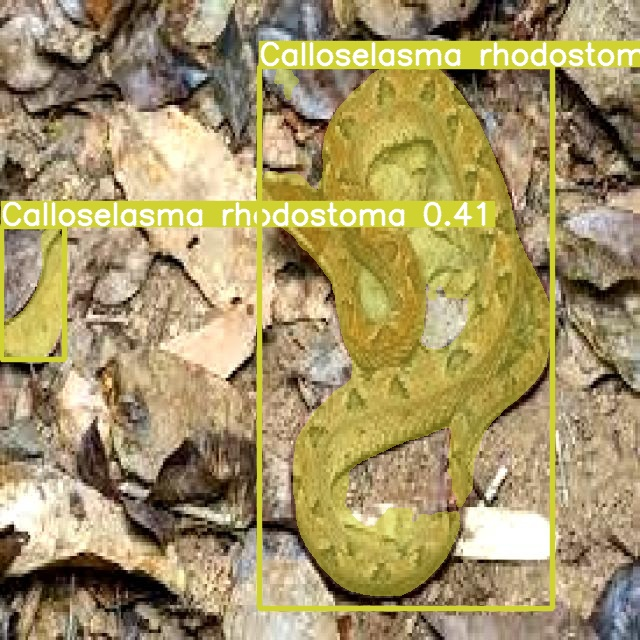

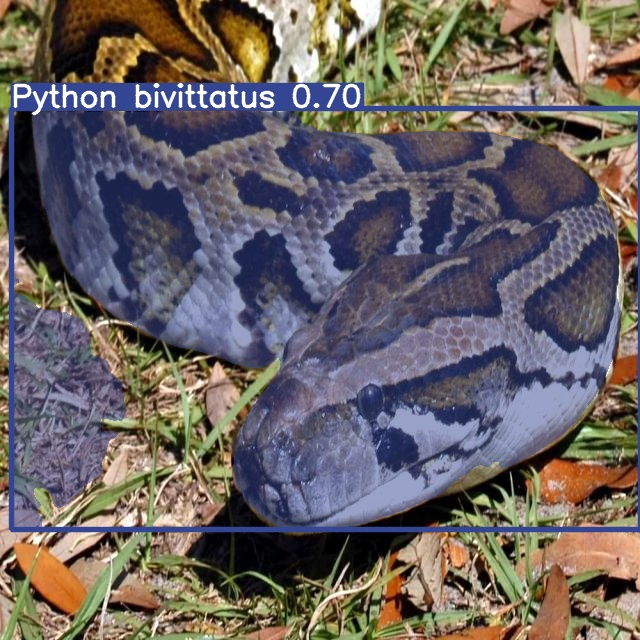

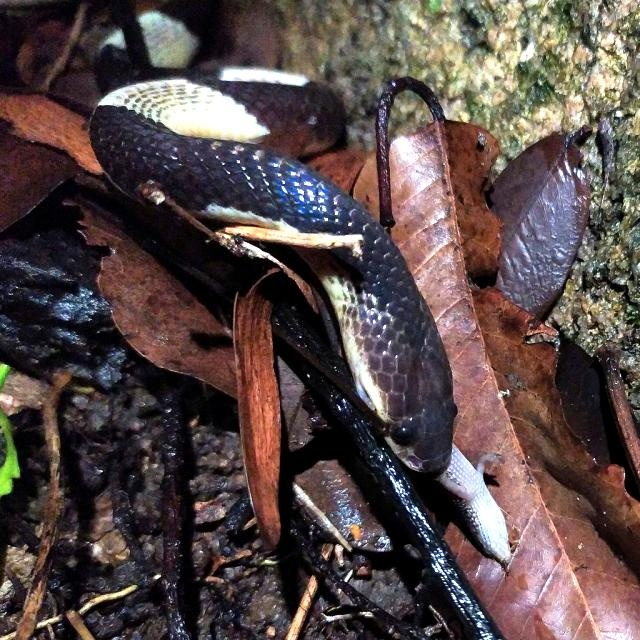

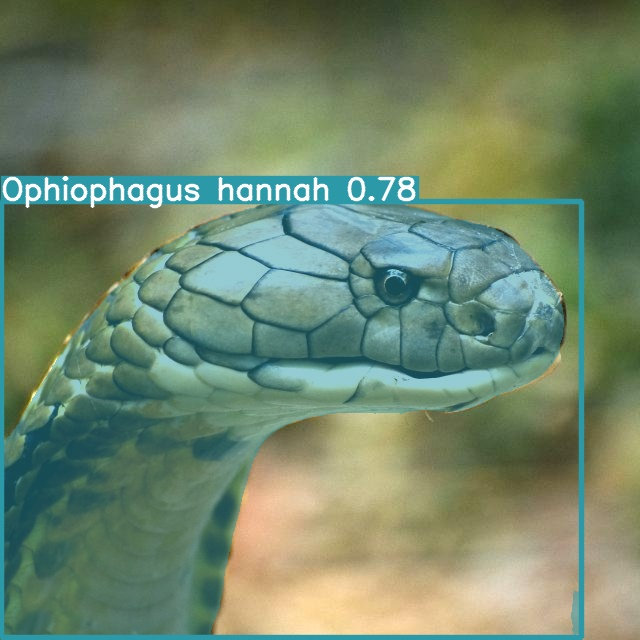

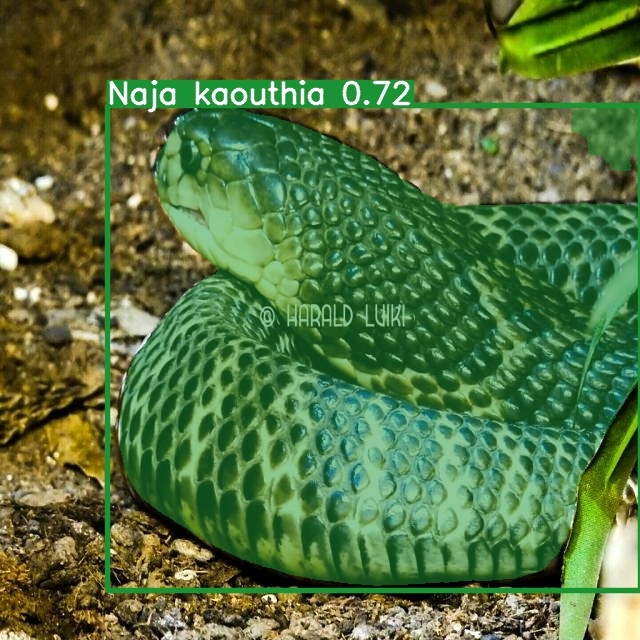

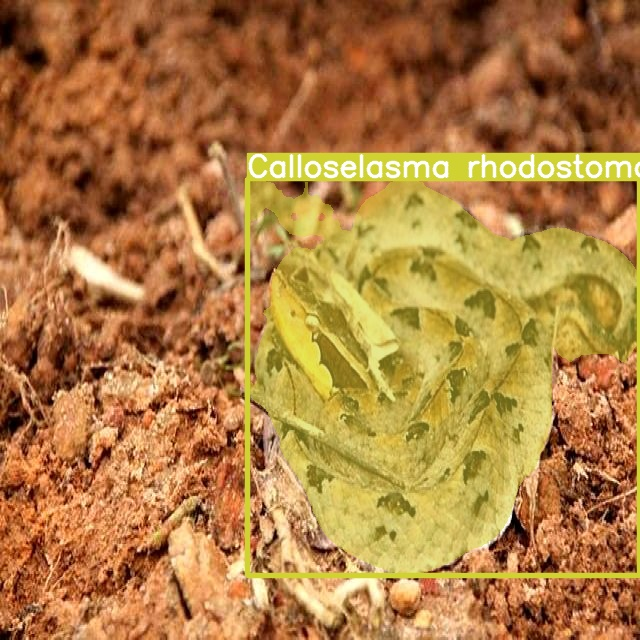

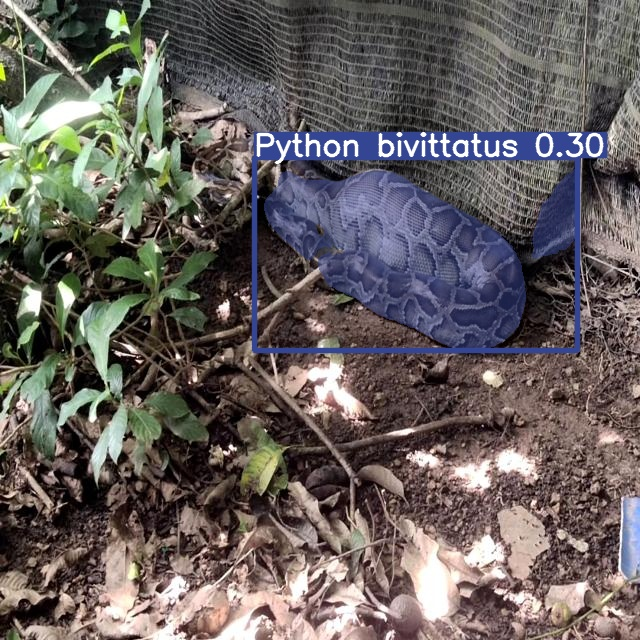

In [15]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'runs/segment/predict/*.jpg'):
      display(Image(filename=image_path, height=600))
      print("\n")